# Time-Series Dynamics & Trend Analysis (EDA Part 2)
## Hourly Pharmaceutical Sales Forecasting Dataset

---

### Executive Summary & Notebook Overview
This notebook focuses on **Time-Series Analysis and Temporal Dynamics** for the hourly pharmaceutical sales dataset (`dataset/saleshourly.csv`). Building upon structural quality checks, this notebook evaluates time-series plots, long-term trends, rolling mean smoothing, rolling volatility clusters, and Period-over-Period growth rates across all 8 ATC drug categories (`M01AB`, `M01AE`, `N02BA`, `N02BE`, `N05B`, `N05C`, `R03`, `R06`).

---

### Table of Contents
1. [13. Time-Series Plot](#13.-Time-Series-Plot)
2. [14. Trend Analysis](#14.-Trend-Analysis)
3. [15. Rolling Mean Analysis](#15.-Rolling-Mean-Analysis)
4. [16. Rolling Volatility Analysis](#16.-Rolling-Volatility-Analysis)
5. [17. Growth Rate Analysis](#17.-Growth-Rate-Analysis)
6. [18. Summary of Findings & Modeling Implications](#18.-Summary-of-Findings-&-Modeling-Implications)

---


In [1]:
!pip install numpy pandas seaborn matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ranje\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Pandas version: 3.0.5
Numpy version: 1.26.4
Matplotlib version: 3.10.5
Seaborn version: 0.13.2


In [ ]:

DATA_PATH = '../dataset/saleshourly_preprocessed.csv'
df_raw = pd.read_csv(DATA_PATH)

df_ts = df_raw.copy()
df_ts['datum_dt'] = pd.to_datetime(df_ts['datum'], format='%m/%d/%Y %H:%M')
df_ts = df_ts.sort_values('datum_dt').set_index('datum_dt')

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

print(f"Time Series Range: {df_ts.index.min()} to {df_ts.index.max()}")
print(f"Total Hourly Timestamps: {len(df_ts):,}")


Time Series Range: 2014-01-02 08:00:00 to 2019-10-08 19:00:00
Total Hourly Timestamps: 50,532


## 13. Time-Series Plot

Visualize full raw hourly sales timelines for all 8 ATC drug categories from January 2014 to October 2019 to inspect overall sales trajectory, magnitude differences, and extreme demand spikes.


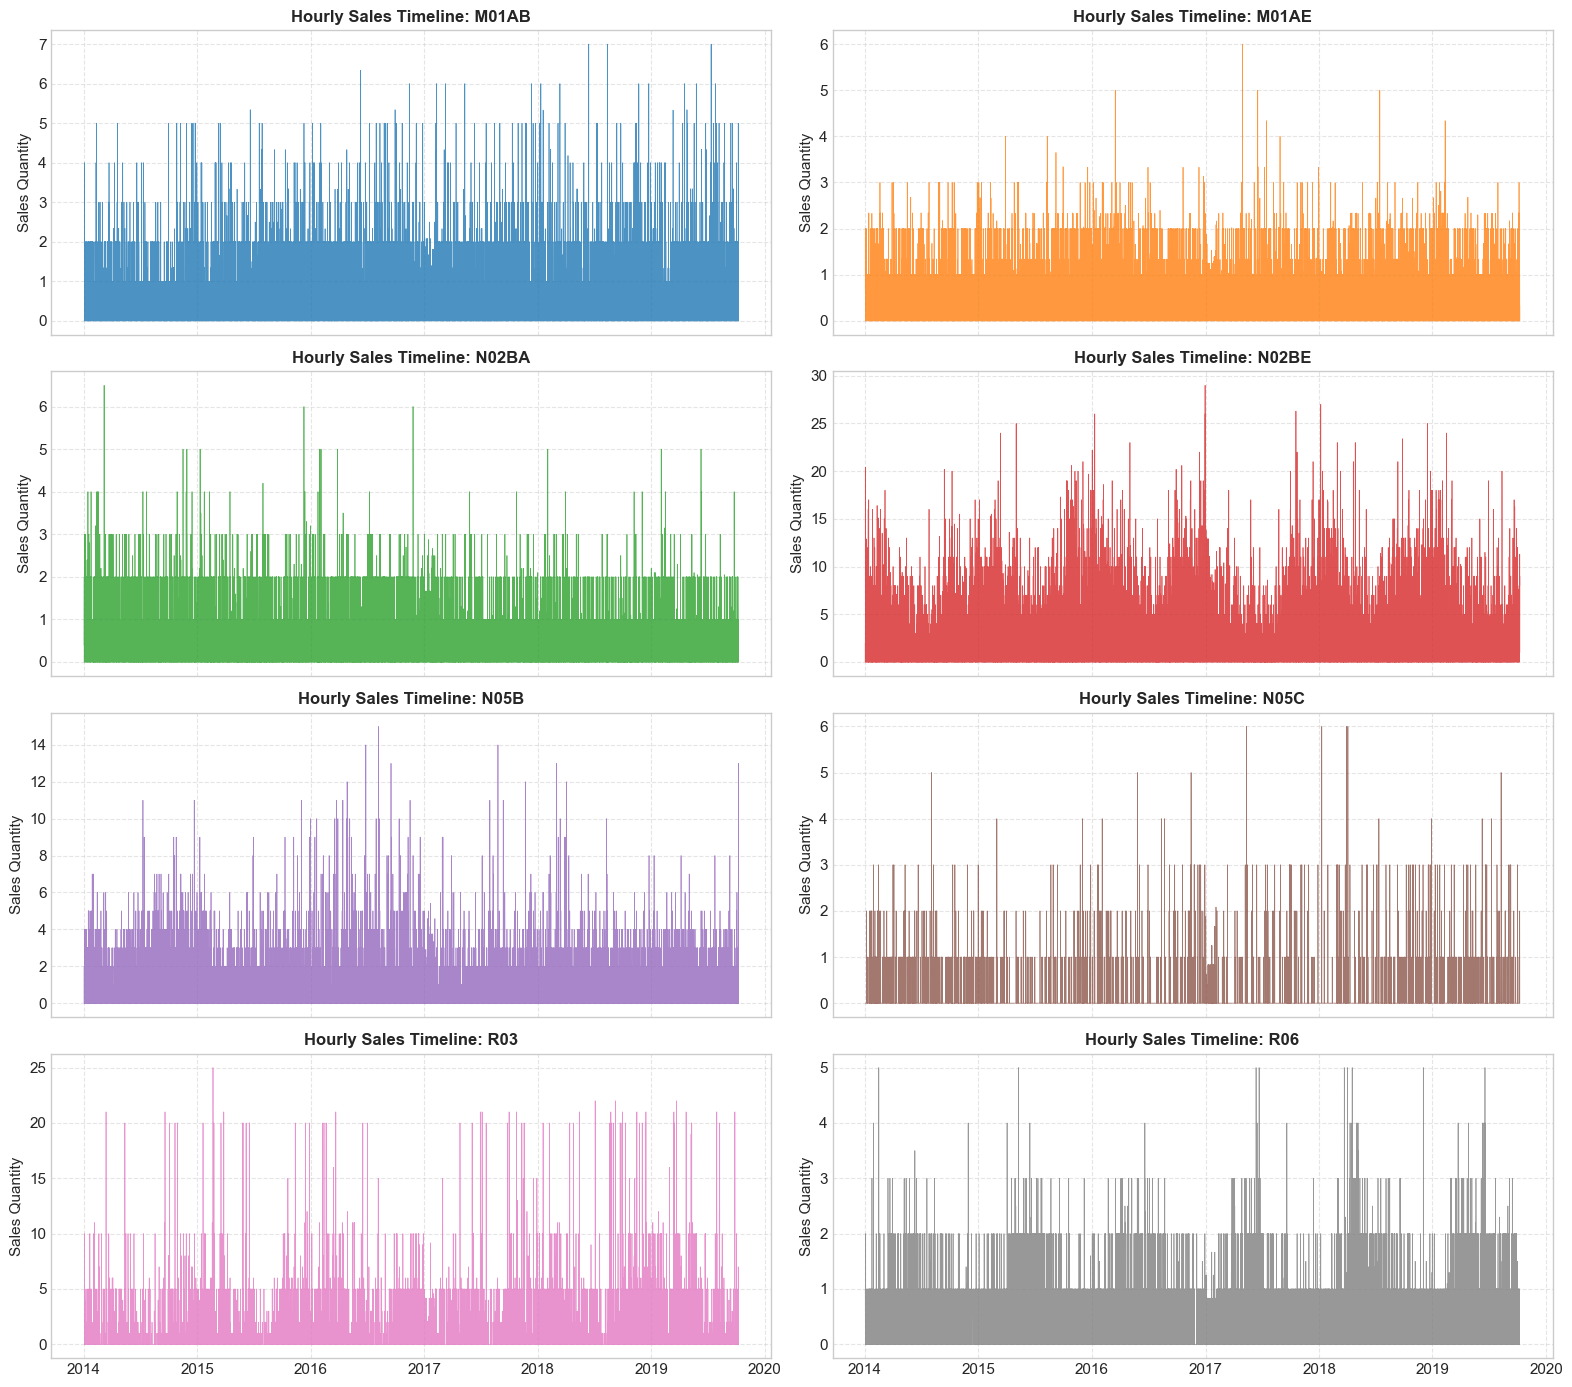

In [5]:

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for idx, col in enumerate(drug_cols):
    axes[idx].plot(df_ts.index, df_ts[col], color=colors[idx], linewidth=0.5, alpha=0.8)
    axes[idx].set_title(f"Hourly Sales Timeline: {col}", fontsize=12, fontweight='bold')
    axes[idx].set_ylabel("Sales Quantity")
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


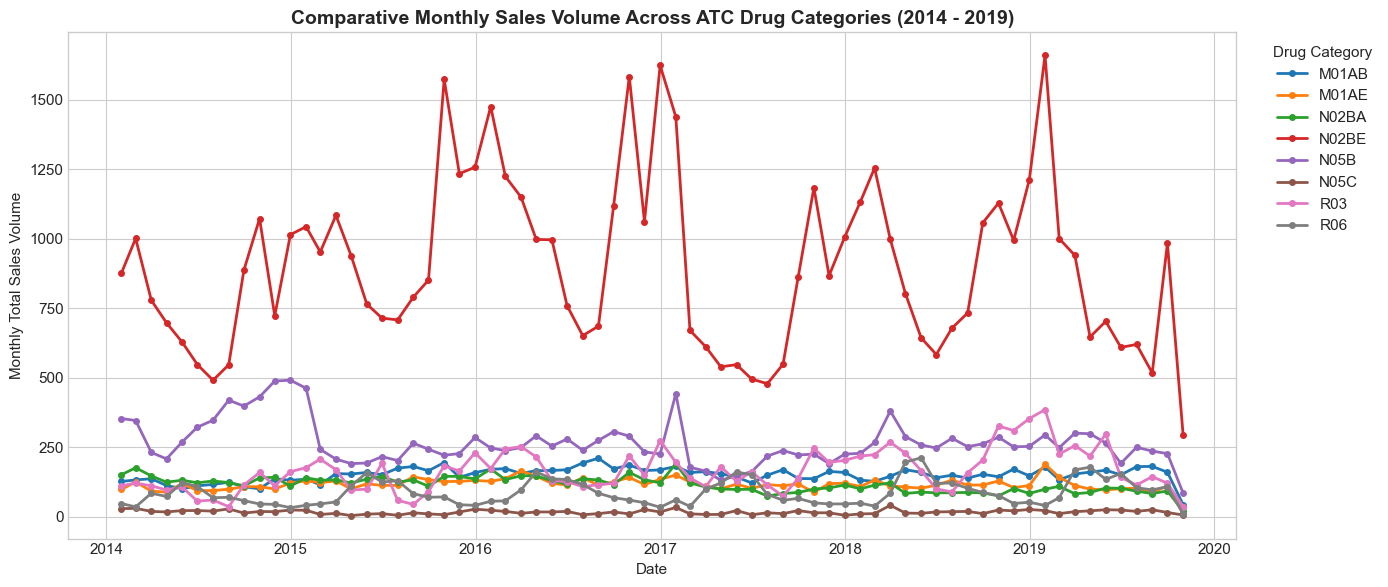

In [6]:

df_monthly = df_ts[drug_cols].resample('ME').sum()

fig, ax = plt.subplots(figsize=(14, 6))
for idx, col in enumerate(drug_cols):
    ax.plot(df_monthly.index, df_monthly[col], label=col, linewidth=2, marker='o', markersize=4)

ax.set_title("Comparative Monthly Sales Volume Across ATC Drug Categories (2014 - 2019)", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Total Sales Volume")
ax.legend(title="Drug Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 14. Trend Analysis

Extract long-term macro trends by resampling hourly data to annual and monthly intervals, and compute centered 30-day (720-hour) moving trends.


In [7]:

annual_sales = df_ts[drug_cols].resample('YE').sum()
annual_sales.index = annual_sales.index.year
annual_sales.index.name = 'Year'

print("Annual Total Sales Volumes by Drug Category:")
annual_sales.style.background_gradient(cmap='YlGn')


Annual Total Sales Volumes by Drug Category:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Year,,,,,,,,
2014,1447.215000,1257.104313,1616.466500,9274.376875,4315.062500,272.625000,1255.000000,800.487500
2015,1895.620000,1496.603000,1608.630000,11923.225000,2965.000000,159.000000,1721.250000,983.030000
2016,2107.285000,1589.441000,1655.216667,13335.580000,3138.333333,207.000000,2137.000000,1065.070000
2017,1846.617083,1387.298333,1288.295833,9258.804833,2555.541667,180.333333,1893.614583,988.860000
2018,1786.930000,1389.656000,1123.800000,11230.925000,3266.200000,235.000000,2655.250000,1196.800000
2019,1517.270000,1084.516000,879.800000,7982.491000,2405.600000,196.000000,1946.708333,1073.570000


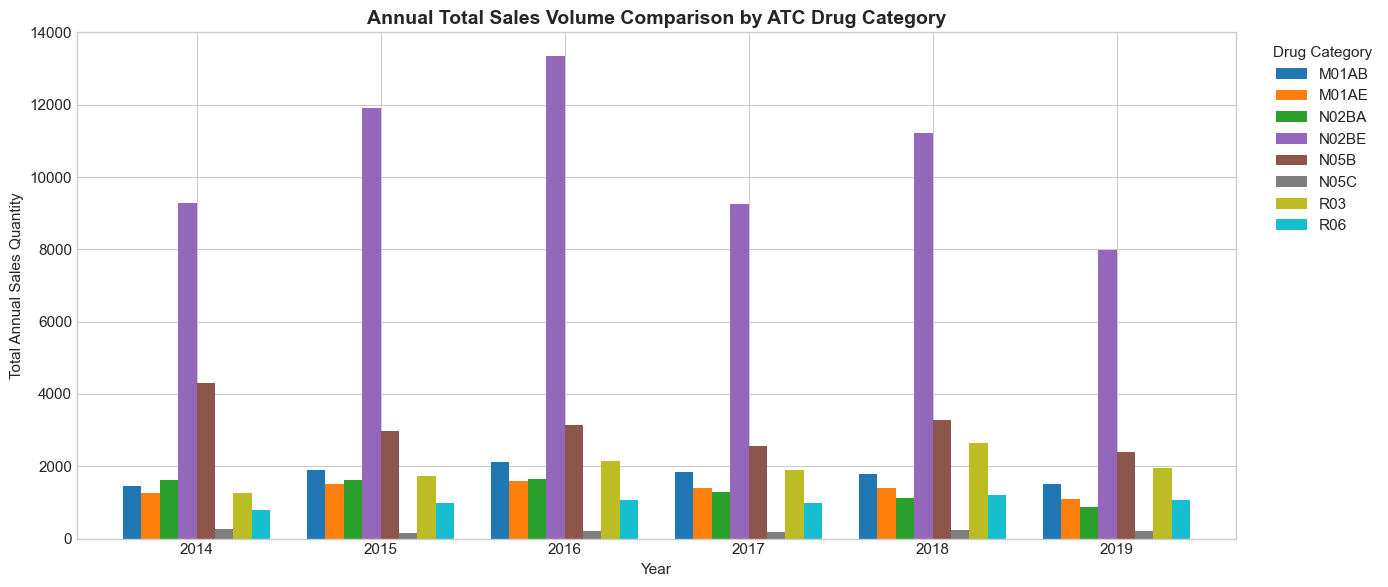

In [ ]:

fig, ax = plt.subplots(figsize=(14, 6))
annual_sales.plot(kind='bar', ax=ax, colormap='tab10', width=0.8)
ax.set_title("Annual Total Sales Volume Comparison by ATC Drug Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Total Annual Sales Quantity")
ax.legend(title="Drug Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


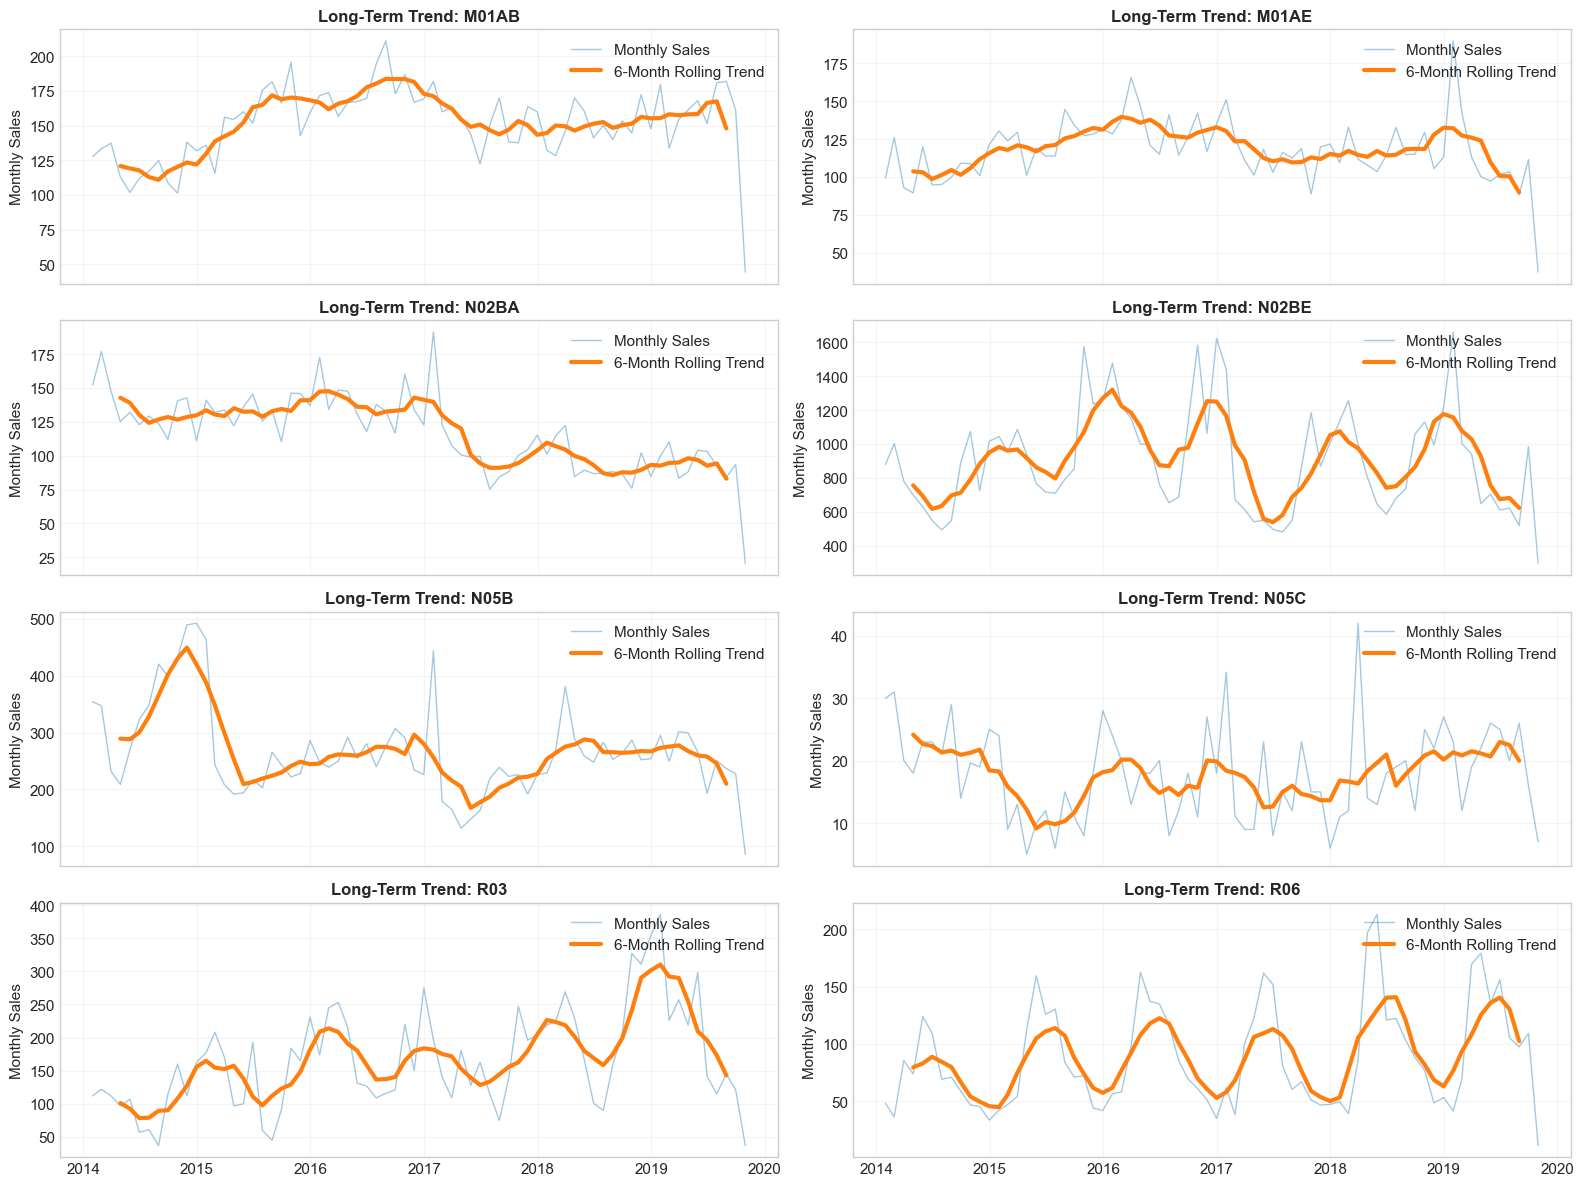

In [ ]:

monthly_sales = df_ts[drug_cols].resample("ME").sum()

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(drug_cols):

    trend_6m = monthly_sales[col].rolling(
        window=6,
        center=True
    ).mean()

    axes[idx].plot(
        monthly_sales.index,
        monthly_sales[col],
        alpha=0.4,
        linewidth=1,
        label="Monthly Sales"
    )

    axes[idx].plot(
        monthly_sales.index,
        trend_6m,
        linewidth=3,
        label="6-Month Rolling Trend"
    )

    axes[idx].set_title(
        f"Long-Term Trend: {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_ylabel("Monthly Sales")
    axes[idx].legend(loc="upper right")
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Annual Sales:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Year,,,,,,,,
2014,1447.22,1257.10,1616.47,9274.38,4315.06,272.62,1255.00,800.49
2015,1895.62,1496.60,1608.63,11923.22,2965.00,159.00,1721.25,983.03
2016,2107.28,1589.44,1655.22,13335.58,3138.33,207.00,2137.00,1065.07
2017,1846.62,1387.30,1288.30,9258.80,2555.54,180.33,1893.61,988.86
2018,1786.93,1389.66,1123.80,11230.92,3266.20,235.00,2655.25,1196.80
2019,1517.27,1084.52,879.80,7982.49,2405.60,196.00,1946.71,1073.57


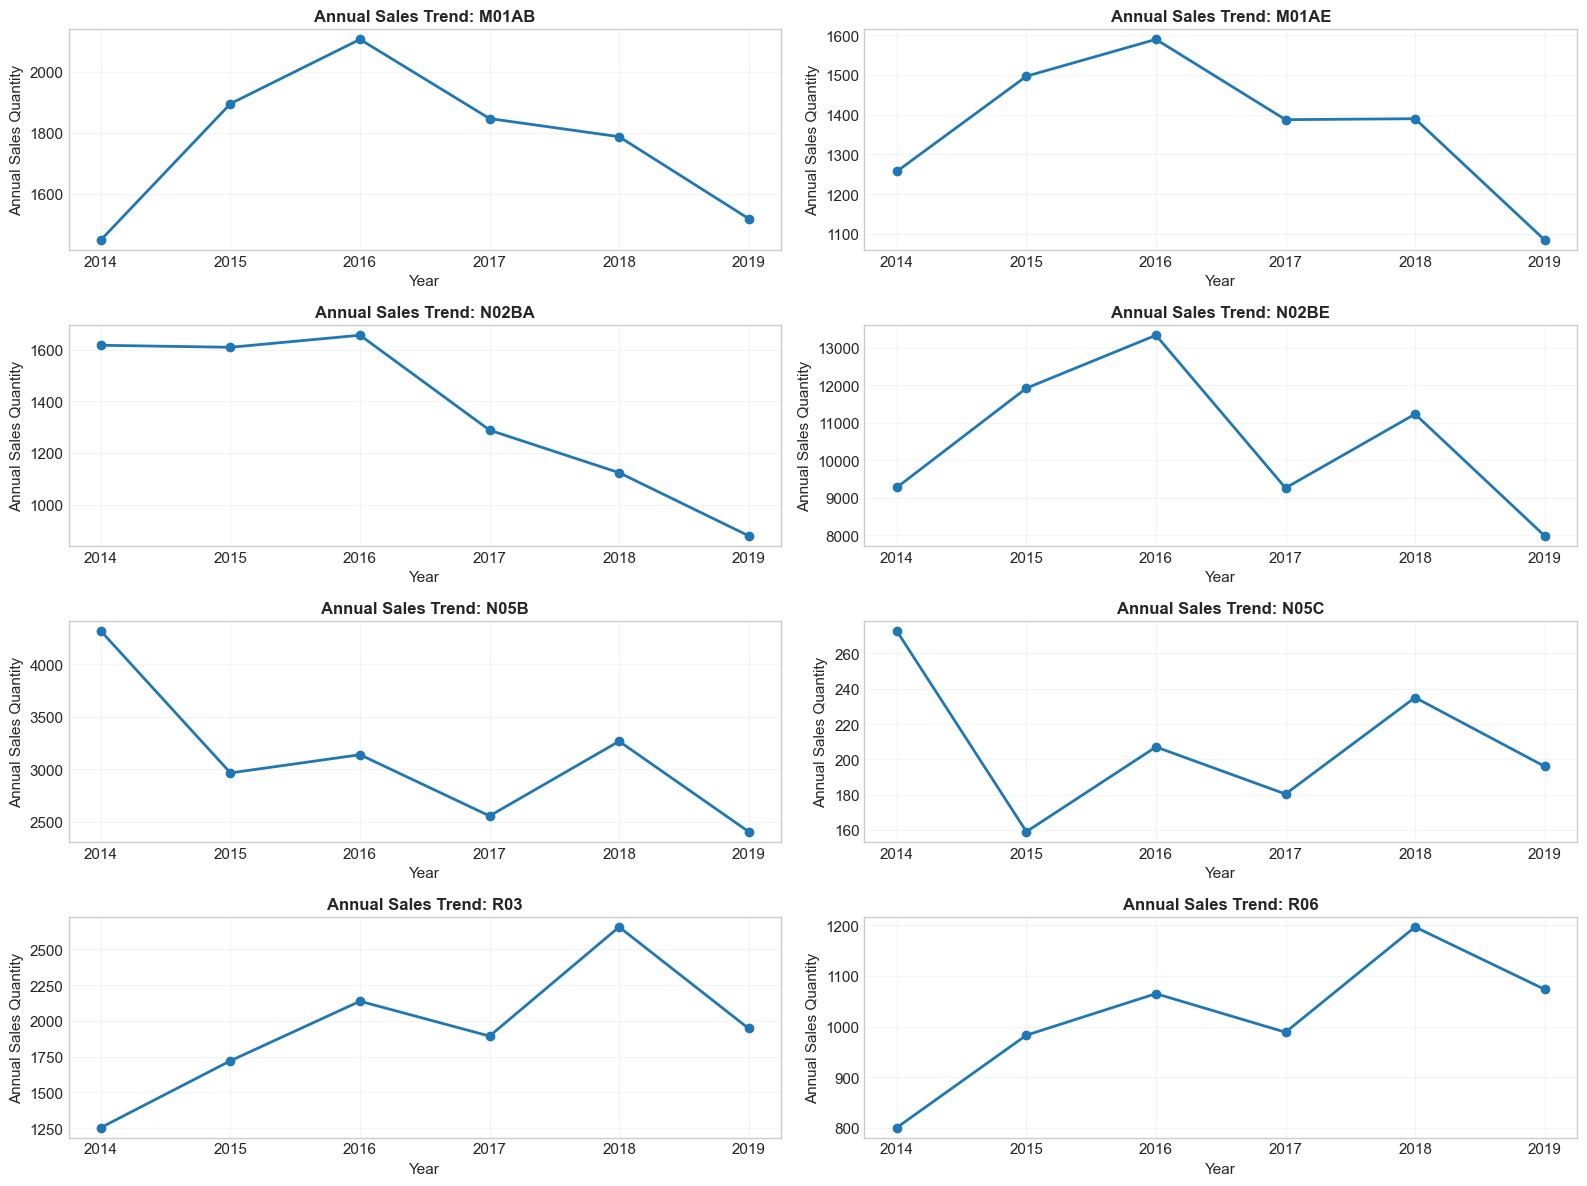

In [16]:

annual_sales = df_ts[drug_cols].resample("YE").sum()

annual_sales.index = annual_sales.index.year
annual_sales.index.name = "Year"

print("Annual Sales:")
display(annual_sales.round(2))

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(drug_cols):

    axes[idx].plot(
        annual_sales.index,
        annual_sales[col],
        marker="o",
        linewidth=2
    )

    axes[idx].set_title(
        f"Annual Sales Trend: {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("Annual Sales Quantity")
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Monthly Sales:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum_dt,,,,,,,,
2014-01-31,127.69,99.090,152.100,878.030,354.0,30.0,112.0,48.2
2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
2014-04-30,113.10,89.475,125.150,698.500,209.0,18.0,97.0,73.7
2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


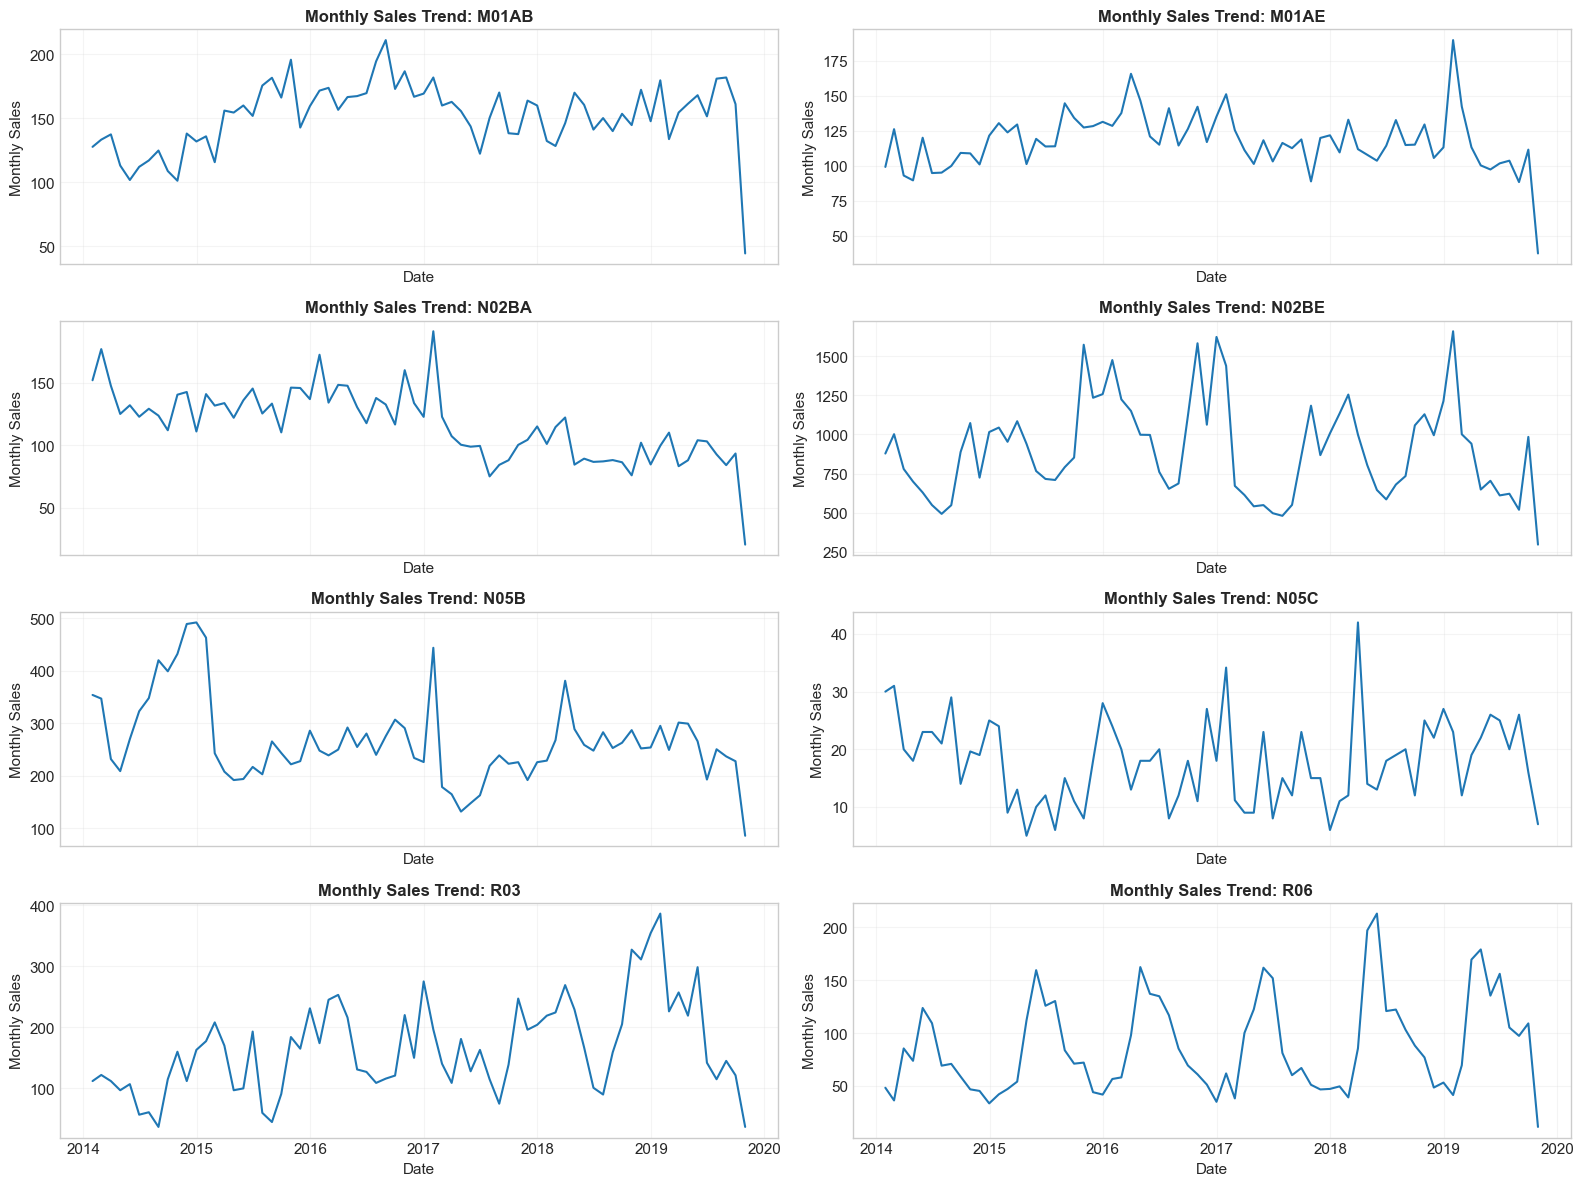

In [ ]:

monthly_sales = df_ts[drug_cols].resample("ME").sum()

print("Monthly Sales:")
display(monthly_sales.head())

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(drug_cols):

    axes[idx].plot(
        monthly_sales.index,
        monthly_sales[col],
        linewidth=1.5
    )

    axes[idx].set_title(
        f"Monthly Sales Trend: {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel("Date")
    axes[idx].set_ylabel("Monthly Sales")
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()

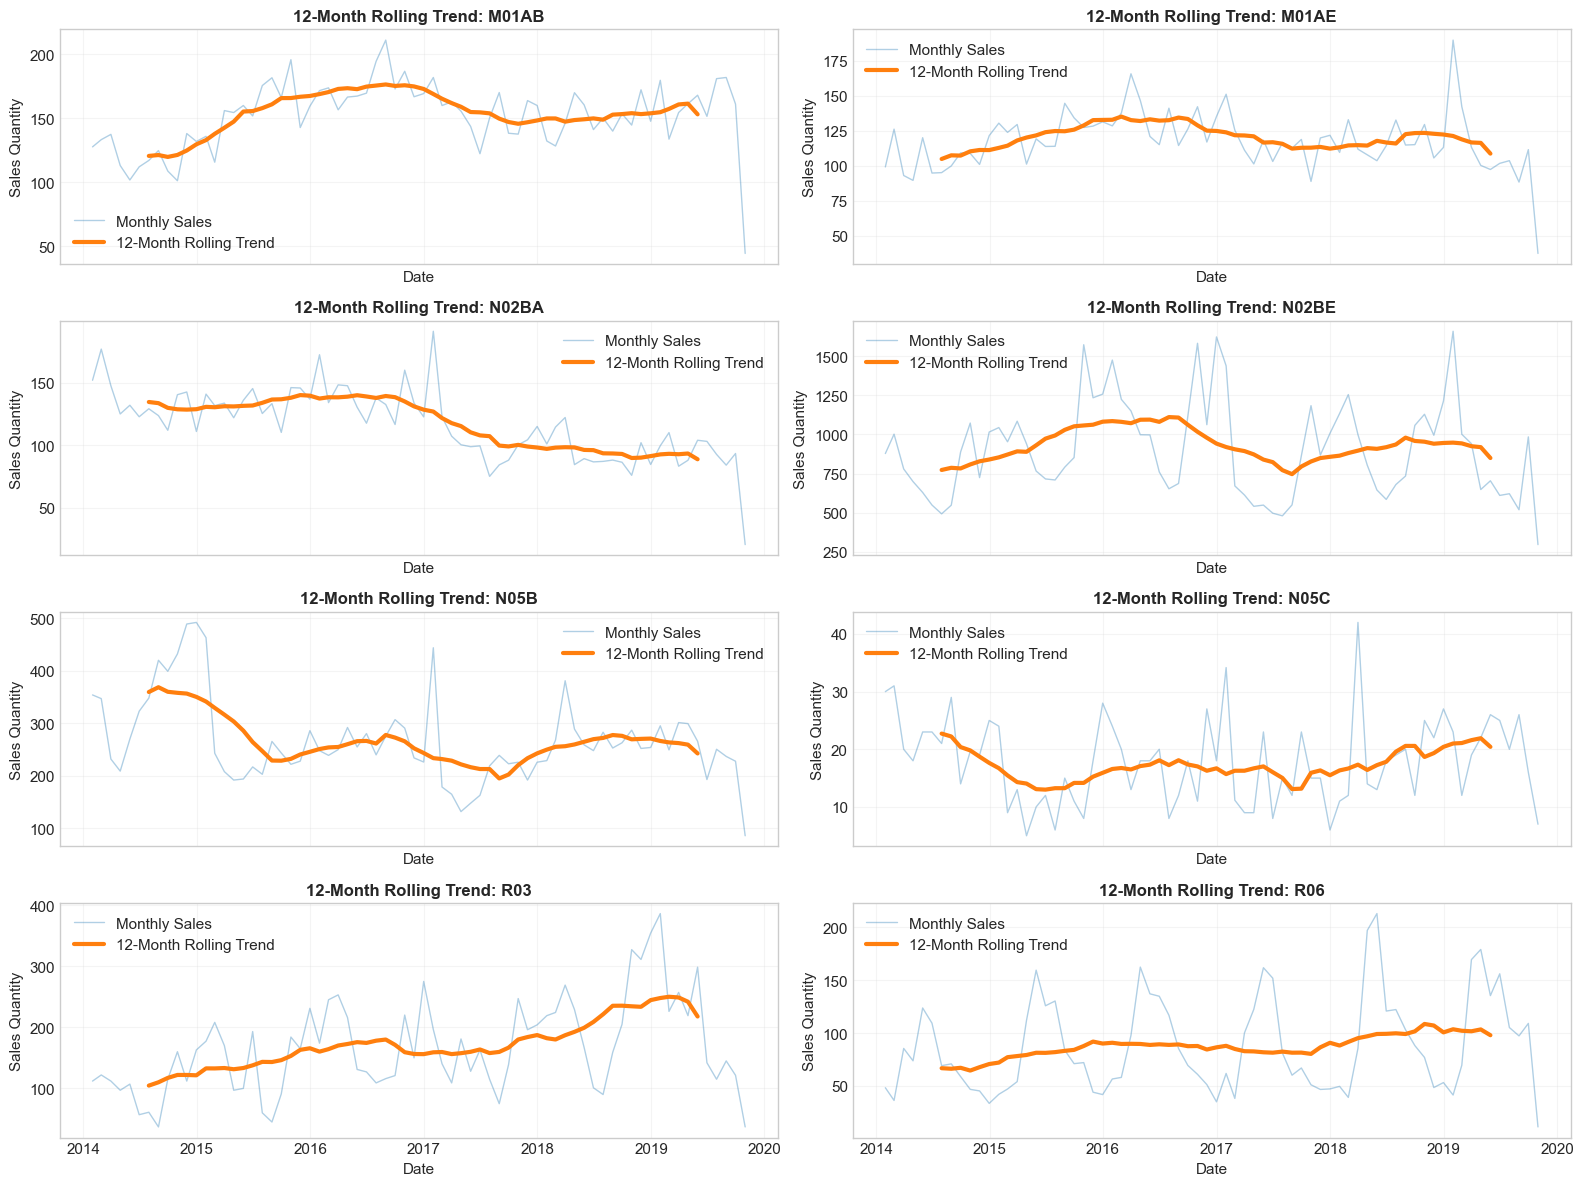

In [17]:


rolling_12m = monthly_sales[drug_cols].rolling(
    window=12,
    center=True
).mean()

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(drug_cols):

    axes[idx].plot(
        monthly_sales.index,
        monthly_sales[col],
        linewidth=1,
        alpha=0.35,
        label="Monthly Sales"
    )

    axes[idx].plot(
        rolling_12m.index,
        rolling_12m[col],
        linewidth=3,
        label="12-Month Rolling Trend"
    )

    axes[idx].set_title(
        f"12-Month Rolling Trend: {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel("Date")
    axes[idx].set_ylabel("Sales Quantity")
    axes[idx].legend()
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Weekly Sales:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum_dt,,,,,,,,
2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


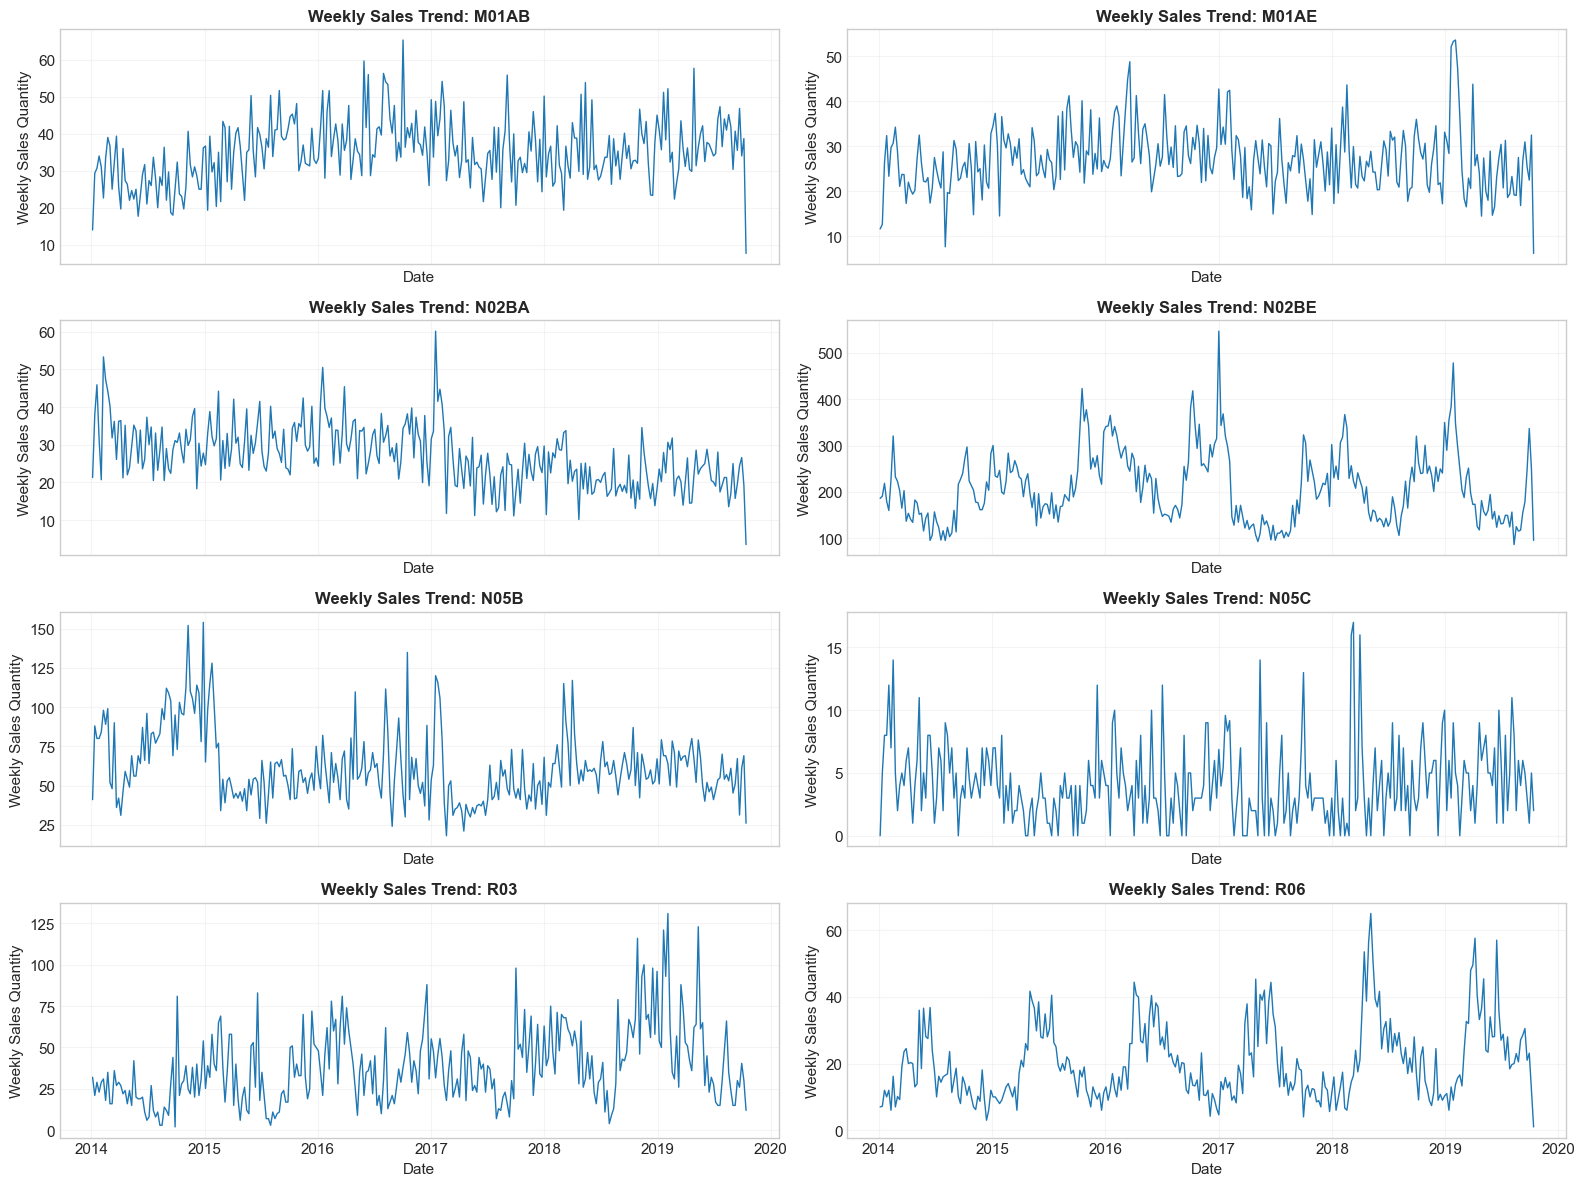

In [18]:


weekly_sales = df_ts[drug_cols].resample("W").sum()

print("Weekly Sales:")
display(weekly_sales.head())

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(drug_cols):

    axes[idx].plot(
        weekly_sales.index,
        weekly_sales[col],
        linewidth=1
    )

    axes[idx].set_title(
        f"Weekly Sales Trend: {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel("Date")
    axes[idx].set_ylabel("Weekly Sales Quantity")
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 15. Rolling Mean Analysis

Evaluate short-term daily (24-hour) and medium-term weekly (168-hour) rolling means to smooth out high-frequency noise and reveal underlying demand cycles.


In [ ]:

rolling_24h = df_ts[drug_cols].rolling(window=24).mean()
rolling_168h = df_ts[drug_cols].rolling(window=168).mean()

rm_summary = pd.DataFrame({
    'Drug Category': drug_cols,
    'Raw Hourly Mean': df_ts[drug_cols].mean().values,
    '24h Rolling Mean Max': rolling_24h.max().values,
    '168h Rolling Mean Max': rolling_168h.max().values,
    'Raw Max Sales': df_ts[drug_cols].max().values
})
rm_summary.set_index('Drug Category').round(4).style.background_gradient(cmap='PuBu')


,Raw Hourly Mean,24h Rolling Mean Max,168h Rolling Mean Max,Raw Max Sales
Drug Category,,,,
M01AB,0.209800,0.778300,0.396800,7.000000
M01AE,0.162400,0.686800,0.354800,6.000000
N02BA,0.161700,0.791700,0.413700,6.500000
N02BE,1.246800,7.541700,3.714400,29.000000
N05B,0.369000,2.409700,0.964300,15.000000
N05C,0.024700,0.416700,0.107100,6.000000
R03,0.229700,1.875000,0.827400,25.000000
R06,0.120900,0.670800,0.392300,5.000000


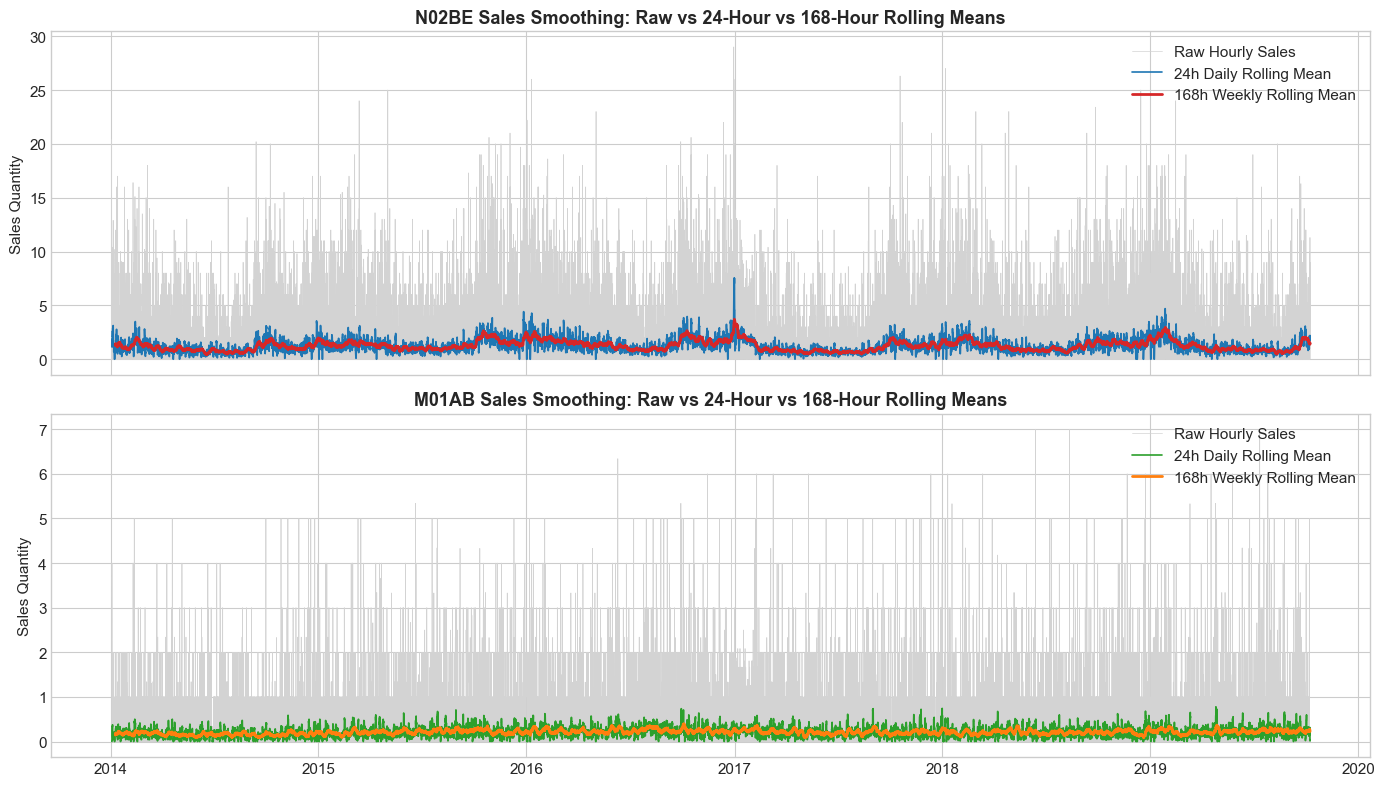

In [ ]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df_ts.index, df_ts['N02BE'], color='lightgray', linewidth=0.5, label='Raw Hourly Sales')
ax1.plot(df_ts.index, rolling_24h['N02BE'], color='#1f77b4', linewidth=1.2, label='24h Daily Rolling Mean')
ax1.plot(df_ts.index, rolling_168h['N02BE'], color='#d62728', linewidth=2.0, label='168h Weekly Rolling Mean')
ax1.set_title("N02BE Sales Smoothing: Raw vs 24-Hour vs 168-Hour Rolling Means", fontsize=13, fontweight='bold')
ax1.set_ylabel("Sales Quantity")
ax1.legend(loc='upper right')

ax2.plot(df_ts.index, df_ts['M01AB'], color='lightgray', linewidth=0.5, label='Raw Hourly Sales')
ax2.plot(df_ts.index, rolling_24h['M01AB'], color='#2ca02c', linewidth=1.2, label='24h Daily Rolling Mean')
ax2.plot(df_ts.index, rolling_168h['M01AB'], color='#ff7f0e', linewidth=2.0, label='168h Weekly Rolling Mean')
ax2.set_title("M01AB Sales Smoothing: Raw vs 24-Hour vs 168-Hour Rolling Means", fontsize=13, fontweight='bold')
ax2.set_ylabel("Sales Quantity")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 16. Rolling Volatility Analysis

Quantify moving demand variance and volatility using 24-hour and 168-hour rolling standard deviations ($s_t$) and Rolling Coefficient of Variation ($CV_t = \sigma_t / \mu_t$).


In [ ]:

rstd_24h = df_ts[drug_cols].rolling(window=24).std()
rstd_168h = df_ts[drug_cols].rolling(window=168).std()

volatility_summary = pd.DataFrame({
    'Drug Category': drug_cols,
    'Overall Std Dev': df_ts[drug_cols].std().values,
    '24h Rolling Std Max': rstd_24h.max().values,
    '168h Rolling Std Max': rstd_168h.max().values,
    '24h Rolling Std Mean': rstd_24h.mean().values
})
volatility_summary.set_index('Drug Category').round(4).style.background_gradient(cmap='Reds')


,Overall Std Dev,24h Rolling Std Max,168h Rolling Std Max,24h Rolling Std Mean
Drug Category,,,,
M01AB,0.556000,1.574200,0.906300,0.504400
M01AE,0.416100,1.294100,0.696800,0.384100
N02BA,0.453200,1.421900,0.806400,0.410300
N02BE,2.387400,9.212400,5.506200,2.114300
N05B,0.930900,3.702700,2.086200,0.807900
N05C,0.217900,1.345300,0.689000,0.107600
R03,1.240500,5.646600,3.014600,0.829100
R06,0.392000,1.419200,0.826600,0.331100


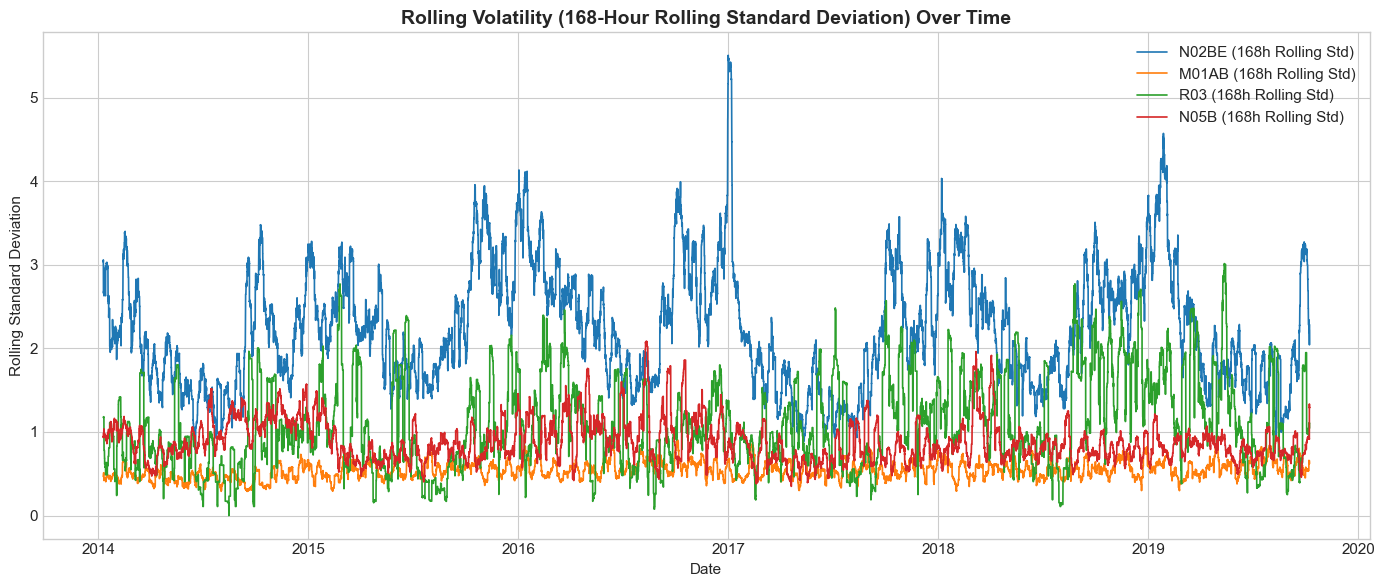

In [ ]:

fig, ax = plt.subplots(figsize=(14, 6))

for col in ['N02BE', 'M01AB', 'R03', 'N05B']:
    ax.plot(df_ts.index, rstd_168h[col], label=f"{col} (168h Rolling Std)", linewidth=1.2)

ax.set_title("Rolling Volatility (168-Hour Rolling Standard Deviation) Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Standard Deviation")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 17. Growth Rate Analysis

Calculate Month-over-Month (MoM) and Year-over-Year (YoY) percentage sales growth rates ($\% \Delta = 
rac{S_t - S_{t-1}}{S_{t-1}} 	imes 100$) to identify growth acceleration and contraction periods.


In [ ]:

monthly_sales = df_ts[drug_cols].resample('ME').sum()
mom_growth = monthly_sales.pct_change() * 100

growth_summary = pd.DataFrame({
    'Drug Category': drug_cols,
    'Average MoM Growth (%)': mom_growth.mean().values,
    'Median MoM Growth (%)': mom_growth.median().values,
    'Max MoM Growth (%)': mom_growth.max().values,
    'Min MoM Growth (%)': mom_growth.min().values,
    'MoM Growth Volatility (Std %)': mom_growth.std().values
})
growth_summary.set_index('Drug Category').round(2).style.background_gradient(cmap='PiYG')


,Average MoM Growth (%),Median MoM Growth (%),Max MoM Growth (%),Min MoM Growth (%),MoM Growth Volatility (Std %)
Drug Category,,,,,
M01AB,0.120000,1.380000,36.450000,-72.450000,15.840000
M01AE,0.530000,0.110000,67.790000,-66.530000,18.860000
N02BA,-0.520000,-0.470000,55.740000,-77.910000,19.110000
N02BE,2.580000,-3.380000,90.020000,-70.020000,29.400000
N05B,0.680000,-0.660000,96.060000,-62.250000,22.590000
N05C,12.860000,0.000000,250.000000,-67.320000,62.210000
R03,7.640000,2.400000,210.810000,-69.530000,48.080000
R06,7.760000,-6.120000,162.730000,-89.800000,49.190000


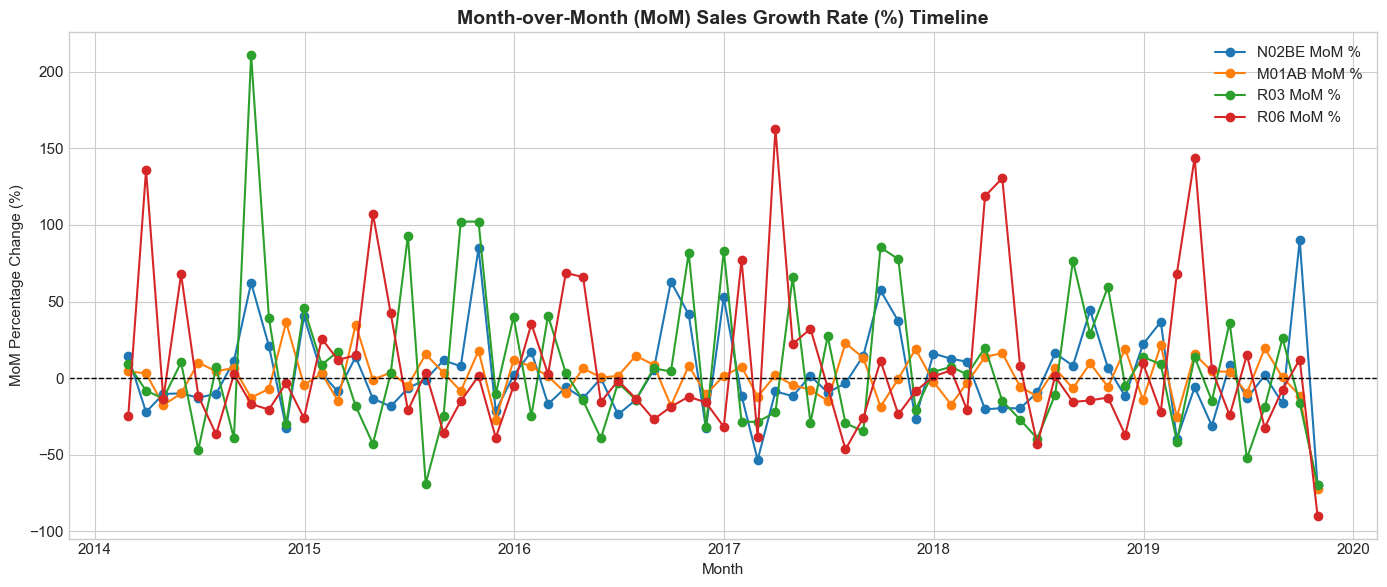

In [ ]:

fig, ax = plt.subplots(figsize=(14, 6))

for col in ['N02BE', 'M01AB', 'R03', 'R06']:
    ax.plot(mom_growth.index, mom_growth[col], marker='o', linewidth=1.5, label=f"{col} MoM %")

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title("Month-over-Month (MoM) Sales Growth Rate (%) Timeline", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("MoM Percentage Change (%)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 18. Summary of Findings & Modeling Implications

Below is the consolidated summary of the Time-Series Dynamics and Trend Analysis findings across modules 13 through 17:

| Analysis Module | Metric / Evaluation | Key Empirical Result | Modeling Implication |
| :--- | :--- | :--- | :--- |
| **13. Time-Series Plot** | Raw Hourly Timelines | `N02BE` dominates total volume (~1.25 units/hr avg); `N05C` has lowest volume (0.025 units/hr). | Multi-scale model training needed due to vast magnitude differences across drug classes. |
| **14. Trend Analysis** | Annual Macro Trends | Peak sales achieved in 2016 (`M01AB`: 2,107 units) and 2018 (`R03`: 2,655 units); slight drop in 2019. | Trend features (time index, year counters, 30-day moving averages) capture macro trajectory. |
| **15. Rolling Means** | 24h & 168h Moving Averages | 24h MA maxes up to 7.54 (`N02BE`); 168h MA maxes up to 3.71 (`N02BE`). | 24h rolling mean captures daily cycles; 168h rolling mean provides strong baseline for weekly demand. |
| **16. Rolling Volatility**| 24h & 168h Rolling Std Dev | Volatility clusters coincide with winter months (flu/cold season peak demand). | Rolling standard deviation (24h/168h) should be included as rolling variance features. |
| **17. Growth Rates** | Month-over-Month (MoM) Growth | Average MoM growth positive for most categories; highest MoM volatility in `N05C` (12.86% avg). | Stationarity transformations (differencing or log-returns) beneficial for linear models (ARIMA/SARIMAX). |

---

### Key Takeaways for Model Engineering
1. **Rolling Feature Inclusion**: Include 24h and 168h rolling means and standard deviations as primary input features for GBDT models (LightGBM/XGBoost).
2. **Seasonality & Trend Extraction**: Incorporate calendar decomposition (Month, Weekday, Hour) alongside 30-day trend features to decouple seasonal fluctuations from underlying growth trends.
3. **Stationarity**: Apply log differencing $\Delta \log(y_t) = \log(y_t) - \log(y_{t-1})$ when training traditional ARIMA/SARIMAX models.
